Setup + preprocessing

In [3]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("Data/weather_crime_final.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['city', 'date'])

Sequence builder

In [4]:
def make_sequences(data, target_col=0, seq_len=14):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, target_col])
    return np.array(X), np.array(y)

LSTM model

In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

Better LSTM model

In [41]:
class BetterLSTM(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=128,
            num_layers=2,
            dropout=0.3,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

Training function

In [6]:
def train_model(X_train, y_train, input_size, epochs=30):
    model = LSTMModel(input_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    X = torch.tensor(X_train, dtype=torch.float32)
    y = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

    return model

MODEL 1: CRIME ONLY

Running Charlottesville


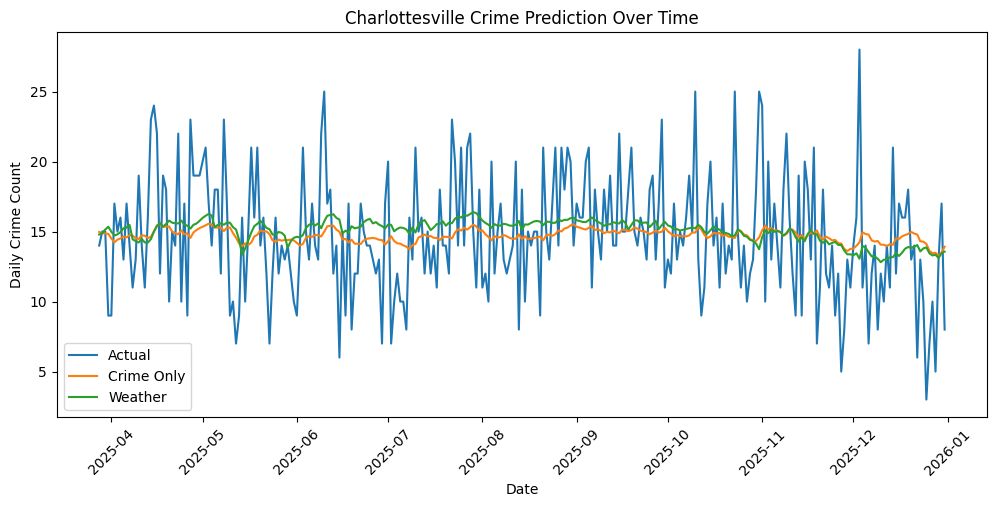

Running Chicago


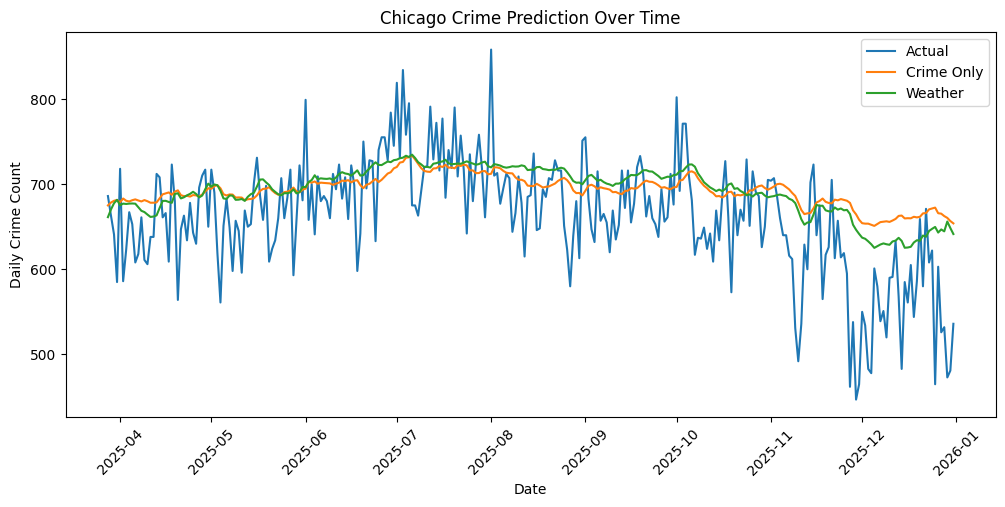

Running Durham


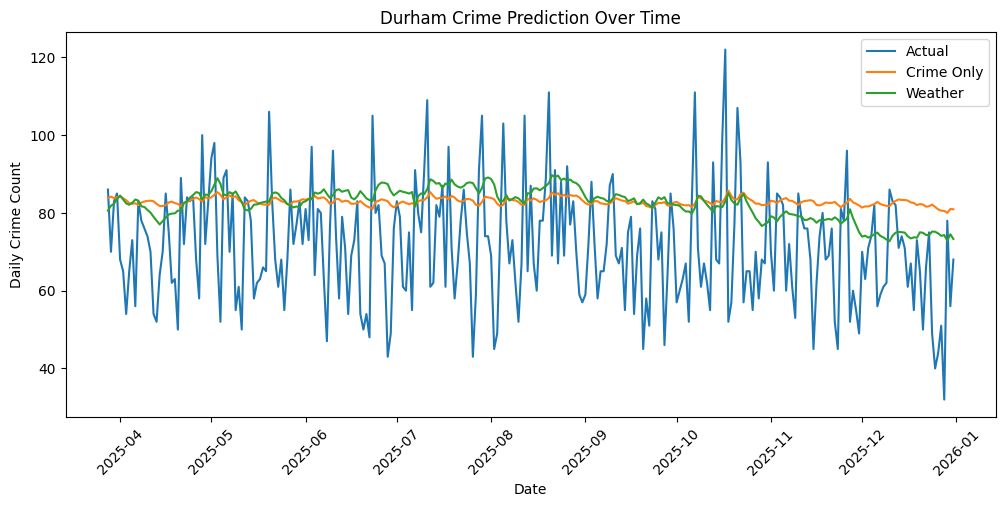

Running NYC


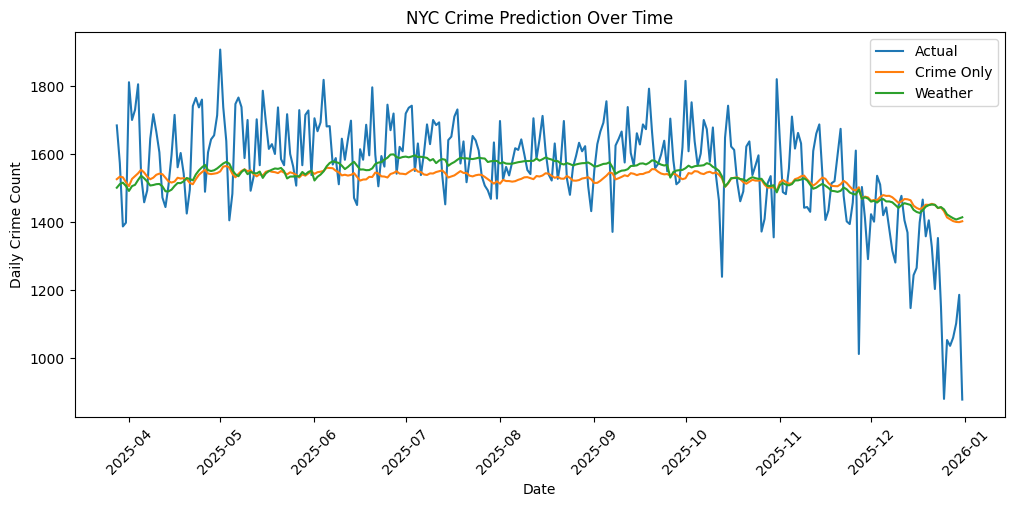

In [ ]:
results = []
cities = df['city'].unique()

for city in cities:
    print(f"Running {city}")
    
    sub = df[df.city == city].copy()
    sub = sub.sort_values("date")

    dates = sub['date'].values

    crime = sub[['total_crime_count']].values

    scaler = StandardScaler()
    crime_scaled = scaler.fit_transform(crime)

    split = int(len(crime_scaled) * 0.8)

    train = crime_scaled[:split]
    test = crime_scaled[split:]

    X_train, y_train = make_sequences(train)
    X_test, y_test = make_sequences(test)

    model1 = train_model(X_train, y_train, input_size=1)

    with torch.no_grad():
        pred1 = model1(torch.tensor(X_test, dtype=torch.float32)).numpy()

    pred1 = scaler.inverse_transform(pred1)
    y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))

    rmse1 = np.sqrt(mean_squared_error(y_test_real, pred1))



    features = ['total_crime_count', 'Daily Temperature Mean', 'Daily Precipitation Sum']
    data = sub[features].values

    scaler2 = StandardScaler()
    data_scaled = scaler2.fit_transform(data)

    train = data_scaled[:split]
    test = data_scaled[split:]

    X_train2, y_train2 = make_sequences(train, target_col=0)
    X_test2, y_test2 = make_sequences(test, target_col=0)

    model2 = train_model(X_train2, y_train2, input_size=3)

    with torch.no_grad():
        pred2 = model2(torch.tensor(X_test2, dtype=torch.float32)).numpy()

    mean = scaler2.mean_[0]
    scale = scaler2.scale_[0]

    pred2 = pred2 * scale + mean
    y_test2 = y_test2 * scale + mean

    rmse2 = np.sqrt(mean_squared_error(y_test2, pred2))


    test_dates = dates[split:][14:]  


    plt.figure(figsize=(12,5))

    plt.plot(test_dates, y_test_real, label="Actual")
    plt.plot(test_dates, pred1, label="Crime Only")
    plt.plot(test_dates, pred2, label="Weather")

    plt.title(f"{city} Crime Prediction Over Time")
    plt.xlabel("Date")
    plt.ylabel("Daily Crime Count")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

    results.append({
        "city": city,
        "crime_only_rmse": rmse1,
        "weather_rmse": rmse2
    })

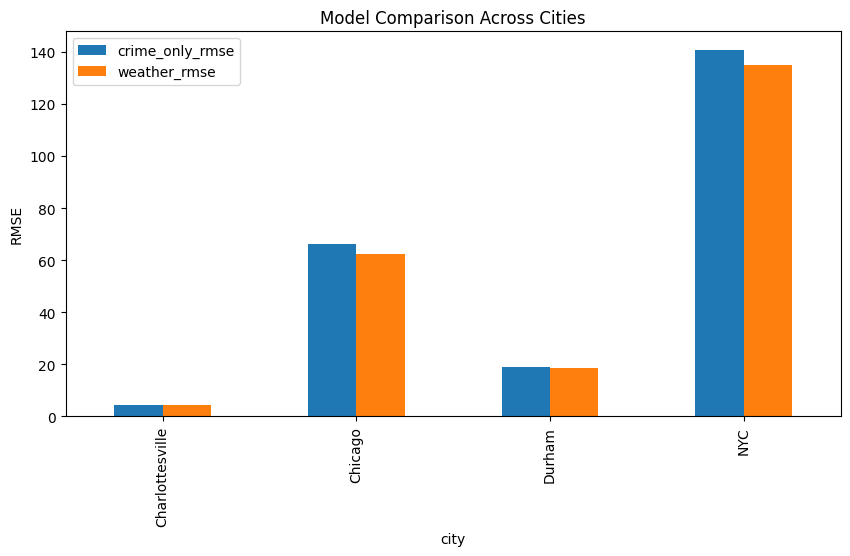

In [18]:
results_df = pd.DataFrame(results)

results_df.set_index("city").plot(kind="bar", figsize=(10,5))
plt.title("Model Comparison Across Cities")
plt.ylabel("RMSE")
plt.show()

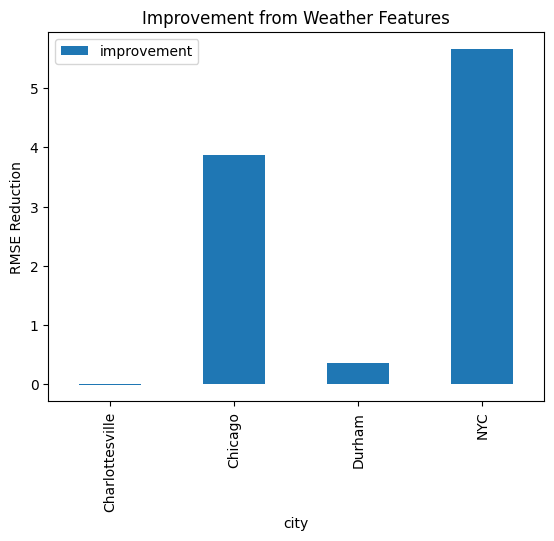

In [19]:
results_df["improvement"] = results_df["crime_only_rmse"] - results_df["weather_rmse"]

results_df.plot(x="city", y="improvement", kind="bar")
plt.title("Improvement from Weather Features")
plt.ylabel("RMSE Reduction")
plt.show()

In [39]:
def train_model1(X_train, y_train, input_size, epochs=100):
    model = BetterLSTM(input_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    X = torch.tensor(X_train, dtype=torch.float32)
    y = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

    return model

Running Charlottesville


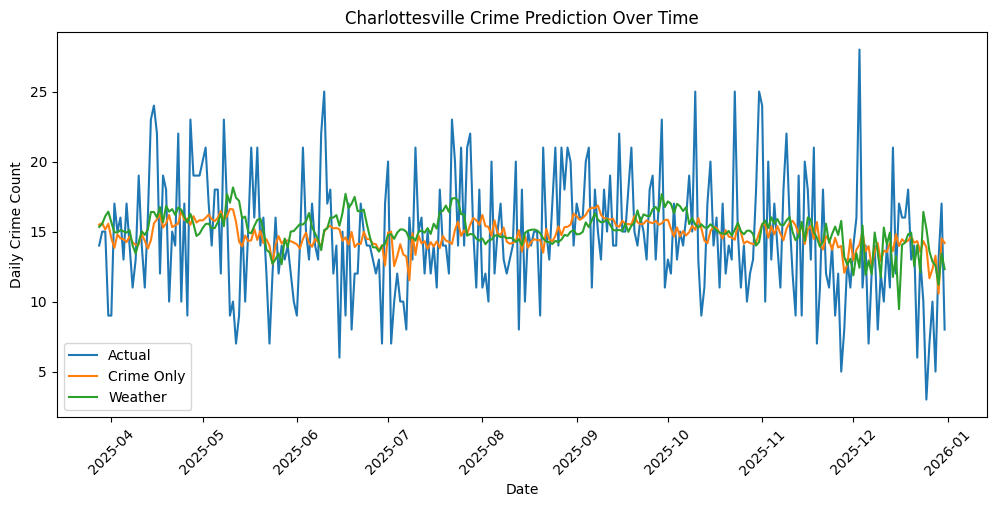

Running Chicago


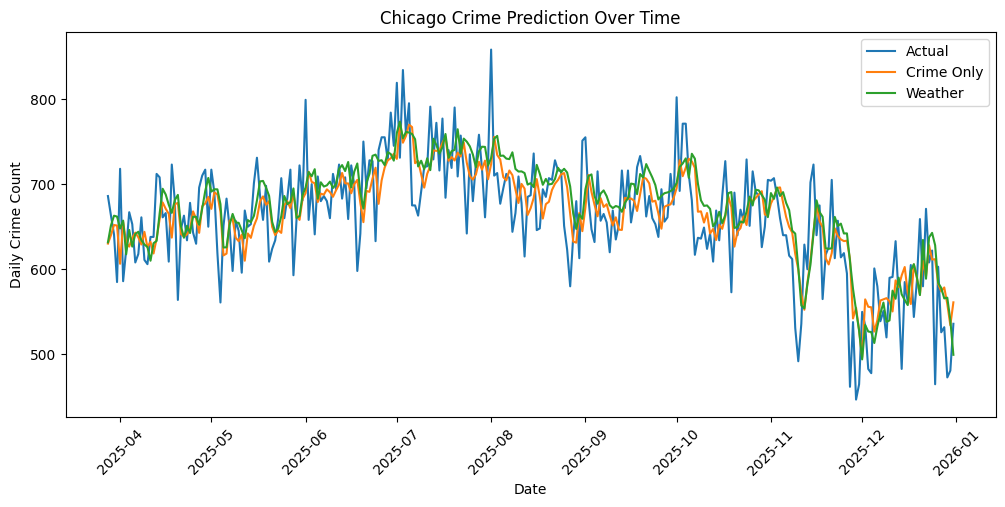

Running Durham


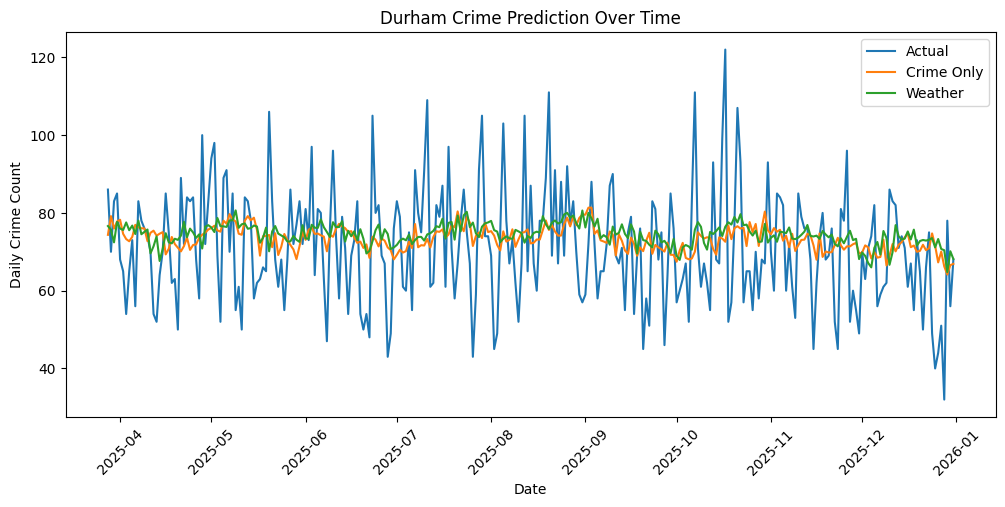

Running NYC


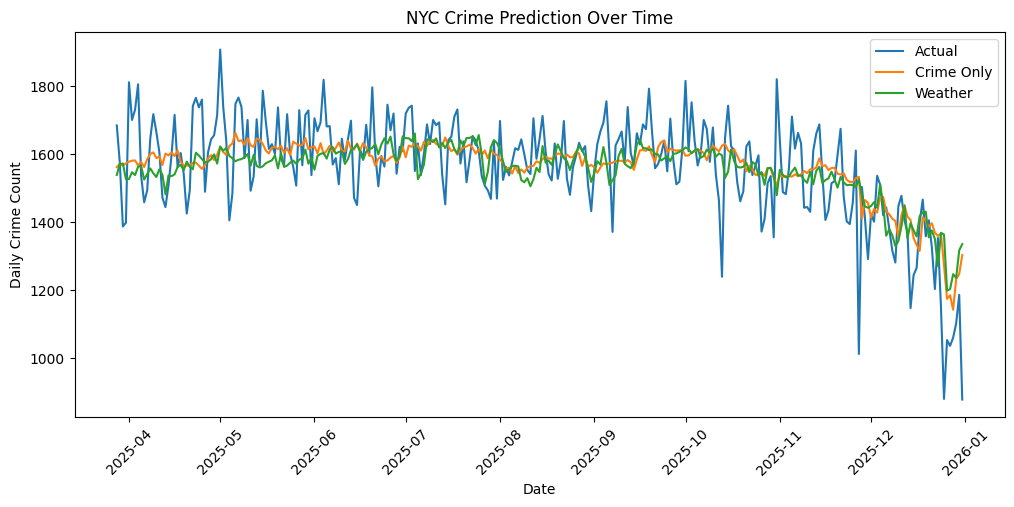

In [42]:
results = []
cities = df['city'].unique()

for city in cities:
    print(f"Running {city}")
    
    sub = df[df.city == city].copy()
    sub = sub.sort_values("date")

    dates = sub['date'].values

    crime = sub[['total_crime_count']].values

    scaler = StandardScaler()
    crime_scaled = scaler.fit_transform(crime)

    split = int(len(crime_scaled) * 0.8)

    train = crime_scaled[:split]
    test = crime_scaled[split:]

    X_train, y_train = make_sequences(train)
    X_test, y_test = make_sequences(test)

    model1 = train_model1(X_train, y_train, input_size=1)

    with torch.no_grad():
        pred1 = model1(torch.tensor(X_test, dtype=torch.float32)).numpy()

    pred1 = scaler.inverse_transform(pred1)
    y_test_real = scaler.inverse_transform(y_test.reshape(-1,1))

    rmse1 = np.sqrt(mean_squared_error(y_test_real, pred1))



    features = ['total_crime_count', 'Daily Temperature Mean', 'Daily Precipitation Sum']
    data = sub[features].values

    scaler2 = StandardScaler()
    data_scaled = scaler2.fit_transform(data)

    train = data_scaled[:split]
    test = data_scaled[split:]

    X_train2, y_train2 = make_sequences(train, target_col=0)
    X_test2, y_test2 = make_sequences(test, target_col=0)

    model2 = train_model1(X_train2, y_train2, input_size=3)

    with torch.no_grad():
        pred2 = model2(torch.tensor(X_test2, dtype=torch.float32)).numpy()

    mean = scaler2.mean_[0]
    scale = scaler2.scale_[0]

    pred2 = pred2 * scale + mean
    y_test2 = y_test2 * scale + mean

    rmse2 = np.sqrt(mean_squared_error(y_test2, pred2))


    test_dates = dates[split:][14:]  


    plt.figure(figsize=(12,5))

    plt.plot(test_dates, y_test_real, label="Actual")
    plt.plot(test_dates, pred1, label="Crime Only")
    plt.plot(test_dates, pred2, label="Weather")

    plt.title(f"{city} Crime Prediction Over Time")
    plt.xlabel("Date")
    plt.ylabel("Daily Crime Count")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

    results.append({
        "city": city,
        "crime_only_rmse": rmse1,
        "weather_rmse": rmse2
    })

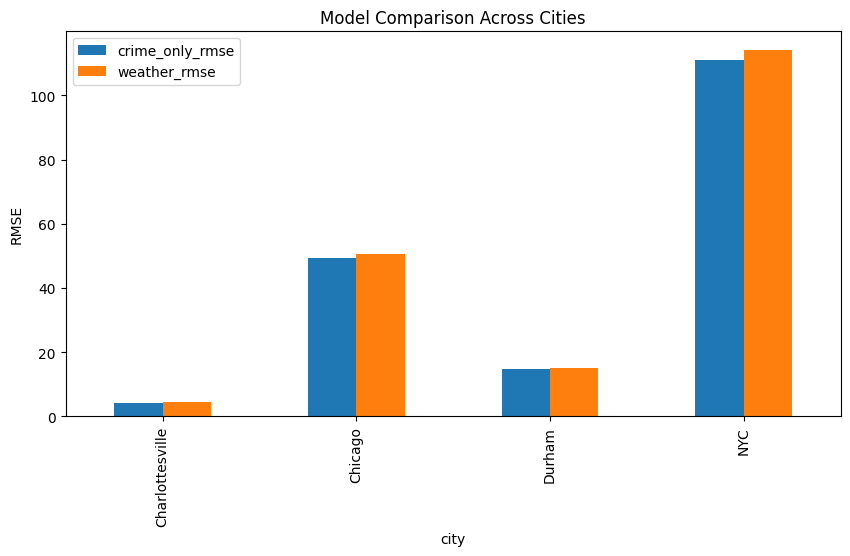

In [43]:
results_df = pd.DataFrame(results)

results_df.set_index("city").plot(kind="bar", figsize=(10,5))
plt.title("Model Comparison Across Cities")
plt.ylabel("RMSE")
plt.show()

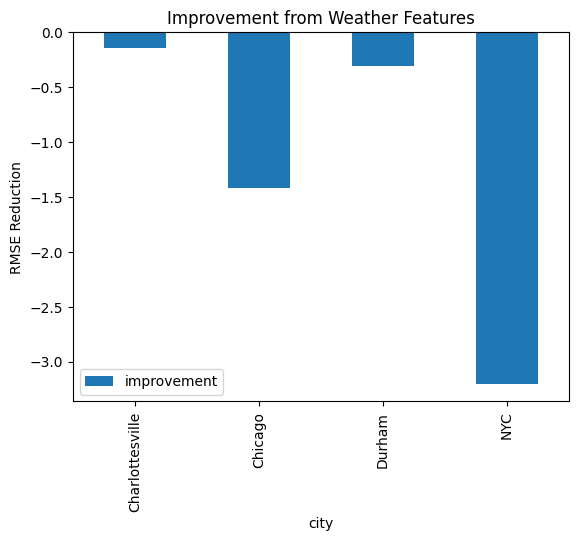

In [44]:
results_df["improvement"] = results_df["crime_only_rmse"] - results_df["weather_rmse"]

results_df.plot(x="city", y="improvement", kind="bar")
plt.title("Improvement from Weather Features")
plt.ylabel("RMSE Reduction")
plt.show()